In [248]:
import matplotlib.pyplot as plt
import numpy as np
import os

In [249]:
color_rng = np.random.default_rng(seed=123)

In [250]:
class Rectangle2D(object):
    def __init__(self, x, y, width, height, label=None, attrs={}):
        self.label = label

        self.x, self.y = x, y
        self.width, self.height = width, height

        self.attrs = attrs

    
    def split(self, position, axis, labels=[None, None]):
        if axis == "H":
            boundary_point = position * self.height
            
            new_attrs = self.attrs.copy()
            new_attrs["facecolor"] = color_rng.random(3)
            bottom_rectangle = Rectangle2D(self.x, self.y, self.width, boundary_point, label=labels[0], attrs=new_attrs)
            
            new_attrs = self.attrs.copy()
            new_attrs["facecolor"] = color_rng.random(3)
            top_rectangle = Rectangle2D(self.x, self.y + boundary_point, self.width, self.height - boundary_point, label=labels[1], attrs=new_attrs)
            return (bottom_rectangle, top_rectangle)
        
        elif axis == "V":
            boundary_point = position * self.width

            new_attrs = self.attrs.copy()
            new_attrs["facecolor"] = color_rng.random(3)
            left_rectangle = Rectangle2D(self.x, self.y, boundary_point, self.height, label=labels[0], attrs=new_attrs)
            
            new_attrs = self.attrs.copy()
            new_attrs["facecolor"] = color_rng.random(3)
            right_rectangle = Rectangle2D(self.x + boundary_point, self.y, self.width - boundary_point, self.height, label=labels[1], attrs=new_attrs)
            return (left_rectangle, right_rectangle)

    
    def get_patch(self):
        return plt.Rectangle((self.x, self.y), self.width, self.height, **self.attrs)

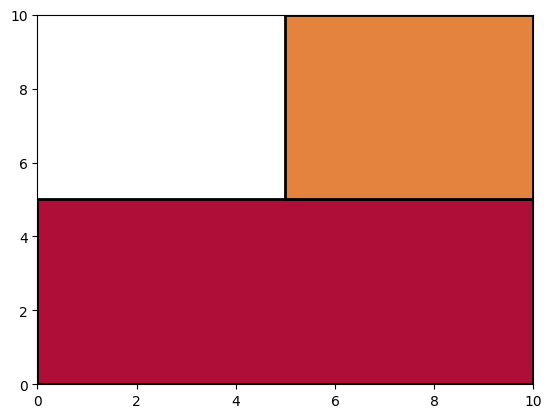

In [251]:
def draw_rectangles(rects):
    fig, ax = plt.subplots()
    
    for r in rects:
        ax.add_patch(r.get_patch())

        if r.label:
            center_x, center_y = r.x + r.width / 2, r.y + r.height / 2
            ax.text(center_x, center_y, r.label[:3], color="black", fontsize=8, ha="center", va='center')
    
    ax.set_xlim(0, max(r.x + r.width for r in rects))
    ax.set_ylim(0, max(r.y + r.height for r in rects))

    plt.show()


root = Rectangle2D(0, 0, 10, 10, attrs={"facecolor": "none", "edgecolor": "black", "linewidth": 2})
bottom, top = root.split(0.5, "H")
top_left, top_right = top.split(0.5, "V")
draw_rectangles([bottom, top_right])

In [252]:
class Parser(object):
    def __init__(self, dir, nonterminals_filename, terminals_filename, rules_filename):
        self.dir = dir
        self.nonterminals_filename = nonterminals_filename
        self.terminals_filename = terminals_filename
        self.rules_filename = rules_filename

    def reset_rng(self):
        self.rng = np.random.default_rng(seed=self.seed)

    def parse_symbols(self):
        with open(os.path.join(self.dir, self.nonterminals_filename), "r") as file:
            nonterminal_symbols = [line.rstrip("\n").upper() for line in file]

        with open(os.path.join(self.dir, self.terminals_filename), "r") as file:
            terminal_symbols = [line.rstrip("\n").lower() for line in file]

        return nonterminal_symbols, terminal_symbols
    
    def parse_rules(self):
        with open(os.path.join(self.dir, self.rules_filename), "r") as file:
            stripped_lines = [line.rstrip("\n") for line in file]
            rules = []
            for line in stripped_lines:
                if "|" in line:
                    all_cases = line.split("|")
                    premise = " ".join(all_cases[0].split()[:2])
                    for i, case in enumerate(all_cases):
                        if i == 0:
                            rules.append(case)
                        else:
                            rules.append(premise + case)
                else:
                    rules.append(line)

        parsed_rules = []
        for rule in rules:
            terms = rule.split()
            premise = terms[0]
            position, axis = float(terms[2][:-1]), terms[2][-1]
            labels = terms[3:]
            parsed_rules.append((premise, position, axis, labels))
        return parsed_rules


parser = Parser("./knowledge_base", "nonterminal_symbols.txt", "terminal_symbols.txt", "rules.txt")

0 ('START', 0.5, 'V', ['FACADE', 'FACADE'])
1 ('FACADE', 0.6, 'H', ['FACADE', 'FACADE'])
2 ('FACADE', 0.5, 'V', ['WALL', 'WALL'])
3 ('FACADE', 0.2, 'H', ['FACADE', 'FACADE'])
4 ('FACADE', 0.2, 'H', ['FACADE', 'FACADE'])
5 ('WALL', 0.7, 'V', ['WALL', 'WINDOW'])
6 ('WALL', 0.7, 'V', ['WALL', 'WINDOW'])
7 ('FACADE', 0.2, 'H', ['FACADE', 'FACADE'])
8 ('FACADE', 0.5, 'V', ['FACADE', 'FACADE'])
9 ('FACADE', 0.6, 'H', ['FACADE', 'FACADE'])


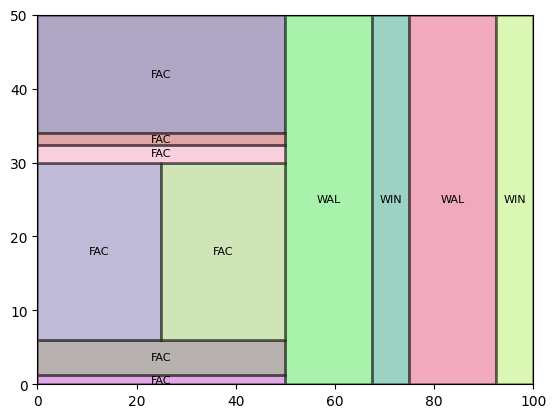

11


In [ ]:
class SplitGrammar(object):
    def __init__(self, dir, seed=0, nonterminals_filename="nonterminal_symbols.txt", 
                 terminals_filename="terminal_symbols.txt", rules_filename="rules.txt"):
        # RNG used to precompute p_r -> should be reset for each building (Wonka et al., 2003)
        self.seed = seed
        self.reset_rng()
        
        self.parser = Parser(dir, nonterminals_filename, terminals_filename, rules_filename)
        
        self.init_symbols()
        self.init_rules()

    def reset_rng(self):
        self.rng = np.random.default_rng(seed=self.seed)
        
    def init_symbols(self):
        nonterminals, terminals = self.parser.parse_symbols()
        self.nonterminals = nonterminals
        self.terminals = terminals

    def init_rules(self):
        # Precompute a random number for each rule to ensure coherence during 
        # rule selection and score matching
        # TODO: determine appropriate lower and upper bounds
        rules = parser.parse_rules()
        self.rules = [(rule, self.rng.random()) for rule in rules]

    def match_rule(self, symbol):
        actionable_rules = self.get_actionable_rules(symbol)
        chosen_rule = self.stochastic_selection(actionable_rules)

        if chosen_rule:
            return chosen_rule[0]
        else:
            return None
    
    def get_actionable_rules(self, symbol):
        return [rule for rule in self.rules if rule[0][0] == symbol]
    
    def stochastic_selection(self, rules):
        # For now, there is no attribute, so the selection is based on p_r only
        if len(rules) == 0:
            return None
        # return sorted(rules, key=lambda x: x[1], reverse=False)[0]
        random_idx = np.random.choice(len(rules))
        return rules[random_idx]

    def build_facade(self, initial_symbol="START"):
        # Add terminal symbols instead of max iterations loop
        initial_object = Rectangle2D(0, 0, 100, 50, label=initial_symbol, attrs={"alpha": 0.4, "edgecolor": "black", "facecolor": "none", "linewidth": 2})
        stack = [initial_object]
        terminals = []
        for i in range(10):           
            current_object = stack.pop(0)
            rule = self.match_rule(current_object.label)

            if rule:
                print(i, rule)
                children = current_object.split(rule[1], rule[2], rule[3])
                stack.extend(children)

            else:
                terminals.append(current_object)

        return stack + terminals

grammar = SplitGrammar("./knowledge_base")
rects = grammar.build_facade()
draw_rectangles(rects)

print(len(rects))